# POS delay — confronto tra baseline predittive e LSTM

Questo notebook confronta tre baseline predittive con il modello LSTM forecasting-based valutato nel notebook `02-delay_type_sensitivity.py`:

1. **seasonal_naive_t7**: usa il valore POS osservato nella settimana precedente;
2. **settlement_kernel_empirical**: stima sul train i pesi del settlement ordinario su `T+1`, `T+2` e `T+3`;
3. **ridge_sequence_window**: usa gli ultimi sette giorni di `pos_card_sales`, le feature calendariali della finestra e `store_id`;
4. **lstm_base**: riusa i risultati della sensitivity analysis POS.

Tutti i modelli sono valutati con la stessa pipeline POS: profile window sui business day, score `pos_cos`, soglie z-score calibrate sulla validation, costruzione delle finestre rilevate e valutazione event-level sulle **effect window**.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/ciok4/jupyter file/tesi')

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import nnls

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tqdm.auto import tqdm

from project_paths import (
    POS_DELAY_RESULTS_DIR,
    POS_DELAY_SENSITIVITY_DIR,
    ensure_artifact_directories,
)

from POS_delay_utils import (
    POS_DELAY_DETECTOR_CONFIG,
    list_pos_delay_sensitivity_datasets,
    pooled_f1,
    pooled_precision,
    pooled_recall,
    prepare_pos_dataframe,
    run_detector_config_on_results,
)

from lstm_utils import summarize_gt_eval_by_type

In [3]:
# =========================================================
# CONFIG
# =========================================================

ensure_artifact_directories()

BASE_SENSITIVITY_PATH = POS_DELAY_SENSITIVITY_DIR

OUTPUT_DIR = POS_DELAY_RESULTS_DIR / "baseline_comparison"
FIGURES_DIR = OUTPUT_DIR / "figures"

for path in [OUTPUT_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TRAIN_SIZE = 0.70
VAL_SIZE = 0.10

# Se True, ignora i risultati salvati e riesegue tutte le baseline.
FORCE_RECOMPUTE = False

# Dataset usato per il plot illustrativo.
DEMO_DELAY_TYPE = "mild_delay"
DEMO_SOURCE_DURATION = 1
DEMO_SEED = 42
DEMO_OUTPUTS_PATH = OUTPUT_DIR / "demo_baseline_outputs.pkl"

# Il kernel considera le componenti ordinarie di settlement T+1, T+2 e T+3.
MAX_ORDINARY_SETTLEMENT_DELAY = 3

# La Ridge usa una finestra di sette giorni, come il modello LSTM POS.
RIDGE_SEQUENCE_WINDOW_SIZE = 7

# Configurazione fissa del detector POS.
BASELINE_DETECTOR_CONFIG = POS_DELAY_DETECTOR_CONFIG.copy()

BASELINE_DETECTOR_CONFIG

{'score_col': 'pos_cos',
 'profile_window_size': 7,
 'z_threshold': 3.5,
 'min_consecutive': 2,
 'gap_tolerance': 1,
 'detected_window_mode': 'profile_windows_union',
 'iou_threshold': 0.2}

## Preparazione dei dati e feature delle baseline

Le funzioni seguenti costruiscono gli split temporali, le feature del kernel di settlement e la rappresentazione a finestra usata dalla Ridge.

Per ogni giorno `t`, `due_pos_amount_k` contiene l'importo POS dei source day per cui `t` è il $k$-esimo business day successivo. Il kernel usa le componenti `T+1`, `T+2` e `T+3`; la Ridge usa invece i valori giornalieri della finestra precedente.

In [4]:
# =========================================================
# SPLIT + PREPROCESSING BASE
# =========================================================

POS_GT_COLS = [
    "is_point_anomaly",
    "pa_type",
    "pa_mult",

    "is_pos_delay_source_day",
    "pos_delay_source_day_in_event",
    "pos_delay_source_duration",

    "is_pos_delay_effect_day",
    "pos_delay_effect_day_in_event",
    "pos_delay_effect_duration",

    "pos_delay_event_id",
    "pos_delay_type",
]

CALENDAR_COLS = [
    "holiday",
    "week_day",
    "month",
    "actual_holiday",
    "pre_holiday",
]


def add_temporal_split(df, train_size=0.70, val_size=0.10):
    """
    Aggiunge split train/val/test per ogni store, mantenendo l'ordine temporale.
    """

    df = df.copy()
    df["split"] = ""

    for store_id, g in df.groupby("store_id"):
        idx = g.sort_values("date").index

        n = len(idx)
        train_end = int(train_size * n)
        val_end = int((train_size + val_size) * n)

        df.loc[idx[:train_end], "split"] = "train"
        df.loc[idx[train_end:val_end], "split"] = "val"
        df.loc[idx[val_end:], "split"] = "test"

    return df


def infer_source_amount_col(df):
    """
    Usa pos_net_amount se disponibile, altrimenti pos_card_sales.

    Nei dataset POS minimi spesso pos_net_amount non è salvata.
    In quel caso la scala viene assorbita dai pesi imparati.
    """

    if "pos_net_amount" in df.columns:
        return "pos_net_amount"

    return "pos_card_sales"


def prepare_baseline_dataframe(
    df,
    train_size=0.70,
    val_size=0.10
):
    """
    Prepara il dataframe giornaliero per le baseline POS.
    """

    df = prepare_pos_dataframe(df)
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

    df["pre_holiday"] = (
        df.groupby("store_id")["actual_holiday"]
          .shift(-1)
          .fillna(0)
          .astype(int)
    )

    df = add_temporal_split(
        df,
        train_size=train_size,
        val_size=val_size
    )

    source_amount_col = infer_source_amount_col(df)
    df["pos_source_amount"] = df[source_amount_col].astype(float)

    return df

In [5]:
# =========================================================
# BUSINESS-DAY SETTLEMENT FEATURES
# =========================================================

def _future_business_dates(date, business_dates, max_delay=3):
    """
    Restituisce i primi max_delay business days strettamente successivi a date.
    """

    date = pd.to_datetime(date)

    future = (
        business_dates[business_dates > date]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    return list(future.iloc[:max_delay])


def add_due_amount_features(
    df,
    amount_col="pos_source_amount",
    max_delay=3,
    holiday_col="holiday"
):
    """
    Costruisce le componenti di settlement sui business day successivi.

    due_pos_amount_k(t) è l'importo POS dei source day per cui t è
    il k-esimo business day successivo.

    Questo gestisce weekend e festività: un source day di sabato può avere
    T+1 il lunedì successivo.
    """

    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store_id", "date"]).copy()

    due_cols = [f"due_pos_amount_{k}" for k in range(1, max_delay + 1)]

    for col in due_cols:
        df[col] = 0.0

    for store_id, g in df.groupby("store_id"):
        g = g.sort_values("date").copy()

        business_dates = (
            g.loc[g[holiday_col].astype(int) == 0, "date"]
             .drop_duplicates()
             .sort_values()
             .reset_index(drop=True)
        )

        date_to_idx = dict(zip(g["date"], g.index))

        for idx, row in g.iterrows():
            amount = float(row[amount_col])

            if not np.isfinite(amount) or amount == 0:
                continue

            future_dates = _future_business_dates(
                row["date"],
                business_dates,
                max_delay=max_delay
            )

            for k, settlement_date in enumerate(future_dates, start=1):
                target_idx = date_to_idx.get(settlement_date)

                if target_idx is None:
                    continue

                df.loc[target_idx, f"due_pos_amount_{k}"] += amount

    df["due_pos_amount_total"] = df[due_cols].sum(axis=1)

    return df

## Baseline 1 — seasonal naive T−7

Questa baseline non viene addestrata: predice `pos_net_cf_t` usando il valore osservato una settimana prima nello stesso store.

In [6]:
def add_seasonal_naive_prediction(
    df,
    target_col="pos_net_cf",
    store_col="store_id",
    date_col="date",
    holiday_col="holiday",
    max_weeks_back=8
):
    """
    Forecaster naive settimanale business-aware.

    Regole:
    - se il giorno target è non lavorativo, predice 0;
    - se il giorno target è lavorativo, usa lo stesso weekday precedente;
    - se t-7 è non lavorativo, cerca t-14, t-21, ...;
    - usa solo valori passati.
    """

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([store_col, date_col]).copy()

    pred_col = "y_pred_seasonal_naive_t7"
    df[pred_col] = np.nan

    for store_id, g in df.groupby(store_col):

        g = g.sort_values(date_col).copy()

        value_by_date = dict(
            zip(
                pd.to_datetime(g[date_col]),
                g[target_col].astype(float)
            )
        )

        holiday_by_date = dict(
            zip(
                pd.to_datetime(g[date_col]),
                g[holiday_col].astype(int)
            )
        )

        preds = []

        for _, row in g.iterrows():

            current_date = pd.to_datetime(row[date_col])
            current_is_holiday = int(row[holiday_col]) == 1

            # Nei giorni non lavorativi non ci si aspetta settlement POS
            if current_is_holiday:
                preds.append(0.0)
                continue

            pred = np.nan

            # Cerca lo stesso weekday nelle settimane precedenti
            for k in range(1, max_weeks_back + 1):

                candidate_date = current_date - pd.Timedelta(days=7 * k)

                if candidate_date not in value_by_date:
                    continue

                candidate_is_business_day = (
                    int(holiday_by_date[candidate_date]) == 0
                )

                if candidate_is_business_day:
                    pred = value_by_date[candidate_date]
                    break

            preds.append(pred)

        df.loc[g.index, pred_col] = preds

    # Fallback causale solo per i primi giorni lavorativi della serie
    business_target = df[target_col].where(
        df[holiday_col].astype(int) == 0
    )

    causal_business_mean = (
        business_target
        .groupby(df[store_col])
        .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    )

    global_business_median = business_target.median()

    df[pred_col] = (
        df[pred_col]
        .fillna(causal_business_mean)
        .fillna(global_business_median)
        .fillna(0.0)
        .clip(lower=0.0)
    )

    # Sicurezza: i giorni non lavorativi devono restare a 0
    df.loc[
        df[holiday_col].astype(int) == 1,
        pred_col
    ] = 0.0

    return df

## Baseline 2 — settlement kernel empirical

Per ogni store, il modello stima sul train i pesi non negativi del settlement ordinario sui primi tre business day successivi:

$$
\widehat{\mathrm{pos\_net\_cf}}_t =
w_1 x_{t,1} + w_2 x_{t,2} + w_3 x_{t,3},
\qquad w_k \geq 0
$$

Qui `x_{t,k}` corrisponde a `due_pos_amount_k(t)`, cioè all'importo POS dei source day per cui il giorno $t$ è il $k$-esimo business day successivo. I source day possono cadere anche in weekend o festività, mentre i giorni di settlement sono business day.

Le componenti oltre `T+3` non sono incluse nel kernel, così il modello descrive il settlement ordinario e gli spostamenti verso giorni più lontani rimangono osservabili nel residuo.

In [7]:
# =========================================================
# BASELINE 2: EMPIRICAL SETTLEMENT KERNEL
# =========================================================

def _fit_nnls_weights(X, y):
    """
    Fit least squares non negativo.
    Restituisce pesi >= 0.
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = (
        np.isfinite(y)
        & np.all(np.isfinite(X), axis=1)
    )

    X = X[mask]
    y = y[mask]

    if len(y) == 0 or np.allclose(X, 0):
        return np.zeros(X.shape[1] if X.ndim == 2 else 0)

    weights, _ = nnls(X, y)
    return weights


def fit_predict_empirical_settlement_kernel(
    df,
    max_delay=3,
    target_col="pos_net_cf",
    fit_per_store=True,
):
    """
    Impara i pesi del kernel di settlement dal train e predice train/val/test.

    Se fit_per_store=True, stima un kernel separato per store.
    In caso di store problematico usa come fallback il kernel globale.
    """

    df = df.copy()

    due_cols = [f"due_pos_amount_{k}" for k in range(1, max_delay + 1)]

    for col in due_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    train_df = df[df["split"] == "train"].copy()

    global_weights = _fit_nnls_weights(
        train_df[due_cols].values,
        train_df[target_col].astype(float).values,
    )

    if len(global_weights) == 0:
        global_weights = np.zeros(len(due_cols))

    df["y_pred_settlement_kernel_empirical"] = 0.0
    weight_rows = []

    for store_id, g in df.groupby("store_id"):
        g = g.sort_values("date").copy()

        if fit_per_store:
            g_train = g[g["split"] == "train"].copy()

            weights = _fit_nnls_weights(
                g_train[due_cols].values,
                g_train[target_col].astype(float).values,
            )

            if len(weights) != len(due_cols) or np.allclose(weights, 0):
                weights = global_weights.copy()
        else:
            weights = global_weights.copy()

        pred = g[due_cols].values @ weights
        df.loc[g.index, "y_pred_settlement_kernel_empirical"] = pred

        row = {"store_id": store_id}
        for k, w in enumerate(weights, start=1):
            row[f"w_T_plus_{k}"] = float(w)
        row["weights_sum"] = float(np.sum(weights))
        weight_rows.append(row)

    df["y_pred_settlement_kernel_empirical"] = (
        df["y_pred_settlement_kernel_empirical"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .clip(lower=0.0)
    )

    learned_weights = pd.DataFrame(weight_rows)

    return learned_weights, df

## Baseline 3 — Ridge con finestra sequenziale

La Ridge usa una rappresentazione tabellare della stessa finestra temporale del modello LSTM POS.
Per predire `pos_net_cf` al giorno $t$, il modello usa:

- i valori di \texttt{pos\_card\_sales} nei 7 giorni precedenti;
- le feature calendariali della stessa finestra: \texttt{holiday}, \texttt{pre\_holiday}, \texttt{week\_day}, \texttt{month};
- lo \texttt{store\_id}.

Le componenti aggregate `due_pos_amount_k` non sono incluse nella Ridge: il modello riceve direttamente i valori giornalieri della finestra.

In [8]:
# =========================================================
# BASELINE 3: RIDGE SEQUENCE-WINDOW
# =========================================================

def make_one_hot_encoder():
    """
    Compatibilità tra versioni diverse di scikit-learn.
    """

    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def add_ridge_sequence_window_features(
    df,
    window_size=7,
    store_col="store_id",
    split_col="split",
):
    """
    Costruisce feature tabellari dalla finestra sequenziale del modello LSTM POS.

    Per ogni giorno target t e per ogni store, usa i giorni precedenti
    all'interno dello stesso split temporale:
    - pos_card_sales[t-window_size], ..., pos_card_sales[t-1]
    - holiday[t-window_size], ..., holiday[t-1]
    - pre_holiday[t-window_size], ..., pre_holiday[t-1]
    - week_day[t-window_size], ..., week_day[t-1]
    - month[t-window_size], ..., month[t-1]

    Le prime window_size righe di ogni split non hanno una finestra completa
    e restano con prediction NaN, come accade implicitamente nella costruzione
    delle sequenze LSTM.
    """

    out = df.copy()
    out = out.sort_values([store_col, "date"]).copy()

    group_keys = [store_col, split_col]

    lag_numeric_base = [
        "pos_card_sales",
        "holiday",
        "pre_holiday",
    ]

    lag_categorical_base = [
        "week_day",
        "month",
    ]

    numeric_features = []
    categorical_features = ["store_id"]

    for lag in range(1, window_size + 1):

        for col in lag_numeric_base:
            feature_name = f"{col}_lag_{lag}"
            out[feature_name] = (
                out.groupby(group_keys, sort=False)[col]
                   .shift(lag)
            )
            numeric_features.append(feature_name)

        for col in lag_categorical_base:
            feature_name = f"{col}_lag_{lag}"
            out[feature_name] = (
                out.groupby(group_keys, sort=False)[col]
                   .shift(lag)
            )
            categorical_features.append(feature_name)

    return out, {
        "num_features": numeric_features,
        "cat_features": categorical_features,
        "window_size": window_size,
    }


def fit_predict_ridge_sequence_window(
    df,
    alpha=1.0,
    window_size=7,
    target_col="pos_net_cf"
):
    """
    Addestra Ridge sul train e produce previsioni su train, validation e test
    usando una rappresentazione tabellare della finestra sequenziale.
    """

    df = df.copy()

    df, feature_info = add_ridge_sequence_window_features(
        df,
        window_size=window_size,
    )

    num_features = feature_info["num_features"]
    cat_features = feature_info["cat_features"]

    model_features = num_features + cat_features

    for col in num_features:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    for col in cat_features:
        df[col] = df[col].astype("object")

    train_df = df[
        (df["split"] == "train")
        & (df["holiday"].astype(int) == 0)
    ].copy()
    
    train_df = train_df.dropna(
        subset=model_features + [target_col]
    ).copy()

    if train_df.empty:
        raise ValueError(
            "Train set vuoto per Ridge sequence-window: "
            "controlla window_size e split temporali."
        )

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", make_one_hot_encoder(), cat_features),
        ],
        remainder="drop",
    )

    model = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", Ridge(alpha=alpha)),
        ]
    )

    X_train = train_df[model_features]
    y_train = train_df[target_col].astype(float)

    model.fit(X_train, y_train)

    df["y_pred_ridge_sequence_window"] = np.nan
    
    valid_mask = (
        (df["holiday"].astype(int) == 0)
        & df[model_features]
            .replace([np.inf, -np.inf], np.nan)
            .notna()
            .all(axis=1)
    )
    
    df.loc[valid_mask, "y_pred_ridge_sequence_window"] = model.predict(
        df.loc[valid_mask, model_features]
    )
    
    df.loc[df["holiday"].astype(int) == 1, "y_pred_ridge_sequence_window"] = 0.0

    df["y_pred_ridge_sequence_window"] = (
        df["y_pred_ridge_sequence_window"]
        .replace([np.inf, -np.inf], np.nan)
        .clip(lower=0.0)
    )

    feature_info.update({
        "model_features": model_features,
        "ridge_representation": "sequence_window",
    })

    return model, df, feature_info

## Detection e valutazione

Ogni baseline produce una previsione giornaliera di `pos_net_cf`.  
Da lì in poi il detector è lo stesso per tutte: profili, z-score, finestre rilevate e valutazione event-level.

In [9]:
# =========================================================
# RESULTS + DETECTOR
# =========================================================

def detector_config_metadata(config):
    """
    Restituisce i parametri del detector da salvare insieme alle metriche.
    Serve a rendere i CSV auto-descrittivi.
    """

    return {
        "score_col": config.get("score_col"),
        "profile_window_size": config.get("profile_window_size"),
        "z_threshold": config.get("z_threshold"),
        "min_consecutive": config.get("min_consecutive"),
        "gap_tolerance": config.get("gap_tolerance"),
        "detected_window_mode": config.get(
            "detected_window_mode",
            "profile_windows_union",
        ),
        "iou_threshold": config.get("iou_threshold"),
    }


def make_baseline_results_df(
    df,
    split,
    pred_col,
    target_col="pos_net_cf"
):
    """
    Converte il dataframe giornaliero nel formato atteso dalla pipeline POS.
    """

    temp = df[df["split"] == split].copy()

    keep_cols = (
        ["date", "store_id", target_col, pred_col]
        + POS_GT_COLS
        + CALENDAR_COLS
    )

    missing = [col for col in keep_cols if col not in temp.columns]

    if missing:
        raise ValueError(f"Mancano colonne per make_baseline_results_df: {missing}")

    results = temp[keep_cols].copy()

    results = results.rename(
        columns={
            target_col: "y_true_original",
            pred_col: "y_pred_original",
        }
    )

    results["y_true"] = results["y_true_original"]
    results["y_pred"] = results["y_pred_original"]

    results = results[
        results["y_true"].notna()
        & results["y_pred"].notna()
    ].copy()

    results["residual"] = results["y_true"] - results["y_pred"]
    results["abs_error"] = results["residual"].abs()
    results["squared_error"] = results["residual"] ** 2

    return results.sort_values(["store_id", "date"]).reset_index(drop=True)


def compute_forecast_metrics(results_df):
    """
    Calcola metriche previsive giornaliere a supporto delle metriche event-level.

    Viene usato WAPE al posto di MAPE perché `pos_net_cf` può essere nullo
    nei giorni non lavorativi.
    """

    y_true = results_df["y_true"].astype(float).values
    y_pred = results_df["y_pred"].astype(float).values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    abs_error_sum = np.abs(y_true - y_pred).sum()
    abs_true_sum = np.abs(y_true).sum()
    wape = abs_error_sum / abs_true_sum if abs_true_sum > 0 else np.nan

    return {
        "mae": mae,
        "rmse": rmse,
        "wape": wape,
    }


def run_three_baselines_on_dataframe(
    df,
    detector_config=None,
    ridge_alpha=1.0,
    train_size=0.70,
    val_size=0.10,
    max_delay=3,
    ridge_window_size=7,
    empirical_kernel_per_store=True,
):
    """
    Esegue le tre baseline su un dataset POS e applica il detector comune.
    """

    base_df = prepare_baseline_dataframe(
        df,
        train_size=train_size,
        val_size=val_size,
    )

    base_df = add_due_amount_features(
        base_df,
        max_delay=max_delay,
    )

    base_df = add_seasonal_naive_prediction(base_df)

    learned_kernel_weights, base_df = fit_predict_empirical_settlement_kernel(
        base_df,
        max_delay=max_delay,
        fit_per_store=empirical_kernel_per_store,
    )

    ridge_model, base_df, ridge_features = fit_predict_ridge_sequence_window(
        base_df,
        alpha=ridge_alpha,
        window_size=ridge_window_size,
    )

    baselines = {
        "seasonal_naive_t7": "y_pred_seasonal_naive_t7",
        "settlement_kernel_empirical": "y_pred_settlement_kernel_empirical",
        "ridge_sequence_window": "y_pred_ridge_sequence_window",
    }

    outputs = {
        "daily_df": base_df,
        "learned_kernel_weights": learned_kernel_weights,
        "ridge_model": ridge_model,
        "ridge_features": ridge_features,
        "baselines": {},
    }

    for baseline_name, pred_col in baselines.items():
        val_results = make_baseline_results_df(
            base_df,
            split="val",
            pred_col=pred_col,
        )

        test_results = make_baseline_results_df(
            base_df,
            split="test",
            pred_col=pred_col,
        )

        config = (
            BASELINE_DETECTOR_CONFIG
            if detector_config is None
            else detector_config
        )

        detector_output = run_detector_config_on_results(
            val_results=val_results,
            test_results=test_results,
            profile_window_size=int(config["profile_window_size"]),
            score_col=config["score_col"],
            z_threshold=float(config["z_threshold"]),
            min_consecutive=int(config["min_consecutive"]),
            gap_tolerance=int(config["gap_tolerance"]),
            iou_threshold=float(config["iou_threshold"]),
        )

        if detector_output is not None:
            detector_output["summary"].update(
                detector_config_metadata(config)
            )

        outputs["baselines"][baseline_name] = {
            "pred_col": pred_col,
            "val_results": val_results,
            "test_results": test_results,
            "forecast_metrics_val": compute_forecast_metrics(val_results),
            "forecast_metrics_test": compute_forecast_metrics(test_results),
            "detector_output": detector_output,
        }

    return outputs

## Esempio su un dataset di sensitivity

In [10]:
# =========================================================
# LOAD DATASET DI ESEMPIO
# =========================================================

demo_datasets_df = list_pos_delay_sensitivity_datasets(
    BASE_SENSITIVITY_PATH,
    source_duration_filter=[DEMO_SOURCE_DURATION],
    delay_types_filter=[DEMO_DELAY_TYPE],
)

demo_datasets_df = demo_datasets_df[
    demo_datasets_df["seed"].astype(int) == DEMO_SEED
].reset_index(drop=True)

if demo_datasets_df.empty:
    raise FileNotFoundError(
        "Dataset di esempio non trovato. Controlla DEMO_DELAY_TYPE, "
        "DEMO_SOURCE_DURATION e DEMO_SEED."
    )

DATA_PATH = demo_datasets_df.loc[0, "path"]

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

print("Dataset di esempio:", DATA_PATH)
df.head()

Dataset di esempio: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\pos_delay\sensitivity\mild_delay\srcdur_1\seed_42\all_stores_cashflow.csv


,date,day,store_id,week_day,month,holiday,actual_holiday,pos_card_sales,pos_net_cf,pos_volume_ratio,...,pa_type,pa_mult,is_pos_delay_source_day,pos_delay_source_day_in_event,pos_delay_source_duration,is_pos_delay_effect_day,pos_delay_effect_day_in_event,pos_delay_effect_duration,pos_delay_event_id,pos_delay_type
0,2018-01-01,1,0,0,1,1,1,37422.07,0.00,0.738507,...,normal,1.0,0,-1,0,0,-1,0,-1,normal
1,2018-01-02,2,0,1,1,0,0,41497.39,29165.23,0.818931,...,normal,1.0,0,-1,0,0,-1,0,-1,normal
2,2018-01-03,3,0,2,1,0,0,48867.00,38589.43,0.964367,...,normal,1.0,0,-1,0,0,-1,0,-1,normal
3,2018-01-04,4,0,3,1,0,0,50116.12,43888.28,0.989017,...,normal,1.0,0,-1,0,0,-1,0,-1,normal
4,2018-01-05,5,0,4,1,0,0,73381.34,43465.88,1.448145,...,normal,1.0,0,-1,0,0,-1,0,-1,normal


In [11]:
# =========================================================
# RUN OR LOAD BASELINES SU DATASET DI ESEMPIO
# =========================================================

if DEMO_OUTPUTS_PATH.exists() and not FORCE_RECOMPUTE:
    with open(DEMO_OUTPUTS_PATH, "rb") as f:
        main_outputs = pickle.load(f)

    print("Risultati dell'esempio caricati da:", DEMO_OUTPUTS_PATH)

else:
    main_outputs = run_three_baselines_on_dataframe(
        df=df,
        detector_config=BASELINE_DETECTOR_CONFIG,
        ridge_alpha=1.0,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        max_delay=MAX_ORDINARY_SETTLEMENT_DELAY,
        ridge_window_size=RIDGE_SEQUENCE_WINDOW_SIZE,
        empirical_kernel_per_store=True,
    )

    with open(DEMO_OUTPUTS_PATH, "wb") as f:
        pickle.dump(main_outputs, f)

    print("Risultati dell'esempio salvati in:", DEMO_OUTPUTS_PATH)

summary_rows = []

for baseline_name, baseline_output in main_outputs["baselines"].items():
    detector_output = baseline_output["detector_output"]

    if detector_output is None:
        continue

    row = {"baseline": baseline_name}
    row.update(detector_output["summary"])
    summary_rows.append(row)

main_summary = pd.DataFrame(summary_rows)
main_summary

Risultati dell'esempio caricati da: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\baseline_comparison\demo_baseline_outputs.pkl


,baseline,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_delay,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,detected_window_mode,iou_threshold
0,seasonal_naive_t7,50,16,4,12,46,0.250000,0.08,0.121212,0.527930,-3.25,pos_cos,7,3.5,2,1,profile_windows_union,0.2
1,settlement_kernel_empirical,50,25,8,17,42,0.320000,0.16,0.213333,0.637273,-1.75,pos_cos,7,3.5,2,1,profile_windows_union,0.2
2,ridge_sequence_window,50,7,1,6,49,0.142857,0.02,0.035088,0.700000,-2.00,pos_cos,7,3.5,2,1,profile_windows_union,0.2


In [12]:
# =========================================================
# PESI IMPARATI DAL KERNEL EMPIRICO
# =========================================================

main_outputs["learned_kernel_weights"]

,store_id,w_T_plus_1,w_T_plus_2,w_T_plus_3,weights_sum
0,0,0.642920,0.256927,0.093843,0.993691
1,1,0.643120,0.252207,0.099328,0.994655
2,2,0.645292,0.251467,0.097426,0.994186
3,3,0.650631,0.245826,0.098820,0.995277
4,4,0.649458,0.245096,0.095648,0.990201
5,5,0.641879,0.249847,0.100933,0.992659
6,6,0.640720,0.253724,0.100910,0.995355
7,7,0.648317,0.251786,0.093048,0.993151
8,8,0.648868,0.248652,0.096765,0.994285
9,9,0.651179,0.240690,0.102069,0.993937


In [13]:
# =========================================================
# METRICHE DI FORECASTING GIORNALIERO
# =========================================================

forecast_rows = []

for baseline_name, baseline_output in main_outputs["baselines"].items():
    row = {"baseline": baseline_name}
    row.update({f"val_{k}": v for k, v in baseline_output["forecast_metrics_val"].items()})
    row.update({f"test_{k}": v for k, v in baseline_output["forecast_metrics_test"].items()})
    forecast_rows.append(row)

main_forecast_metrics = pd.DataFrame(forecast_rows)
main_forecast_metrics

,baseline,val_mae,val_rmse,val_wape,test_mae,test_rmse,test_wape
0,seasonal_naive_t7,7601.967211,15756.856132,0.187884,7599.002330,16796.784174,0.185850
1,settlement_kernel_empirical,3320.510669,5765.733043,0.082067,3632.948927,7388.445370,0.088852
2,ridge_sequence_window,4902.137512,8308.233390,0.122228,5173.463199,9415.726693,0.126695


In [14]:
# =========================================================
# RISULTATI PER TIPO DI POS DELAY
# =========================================================

main_by_type_rows = []

for baseline_name, baseline_output in main_outputs["baselines"].items():
    detector_output = baseline_output["detector_output"]

    if detector_output is None:
        continue

    gt_eval = detector_output["gt_eval"]

    if gt_eval.empty:
        continue

    temp = summarize_gt_eval_by_type(gt_eval)
    temp.insert(0, "baseline", baseline_name)
    main_by_type_rows.append(temp)

main_by_type = (
    pd.concat(main_by_type_rows, ignore_index=True)
    if main_by_type_rows
    else pd.DataFrame()
)

main_by_type

,baseline,gt_type,n_events,detected_events,recall,mean_iou,mean_detection_delay,missed_events
0,seasonal_naive_t7,mild_delay,50,4,0.08,0.527930,-3.25,46
1,settlement_kernel_empirical,mild_delay,50,8,0.16,0.637273,-1.75,42
2,ridge_sequence_window,mild_delay,50,1,0.02,0.700000,-2.00,49


In [15]:
# =========================================================
# SALVATAGGIO RISULTATI DI ESEMPIO
# =========================================================

main_summary.to_csv(
    OUTPUT_DIR / "demo_baseline_summary.csv",
    index=False,
)

main_by_type.to_csv(
    OUTPUT_DIR / "demo_baseline_summary_by_type.csv",
    index=False,
)

main_forecast_metrics.to_csv(
    OUTPUT_DIR / "demo_baseline_forecast_metrics.csv",
    index=False,
)

main_outputs["learned_kernel_weights"].to_csv(
    OUTPUT_DIR / "demo_empirical_kernel_weights.csv",
    index=False,
)

OUTPUT_DIR

WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/baseline_comparison')

## Plot rapido

Il plot mostra serie reale, previsioni delle tre baseline e effect window del dataset di esempio.

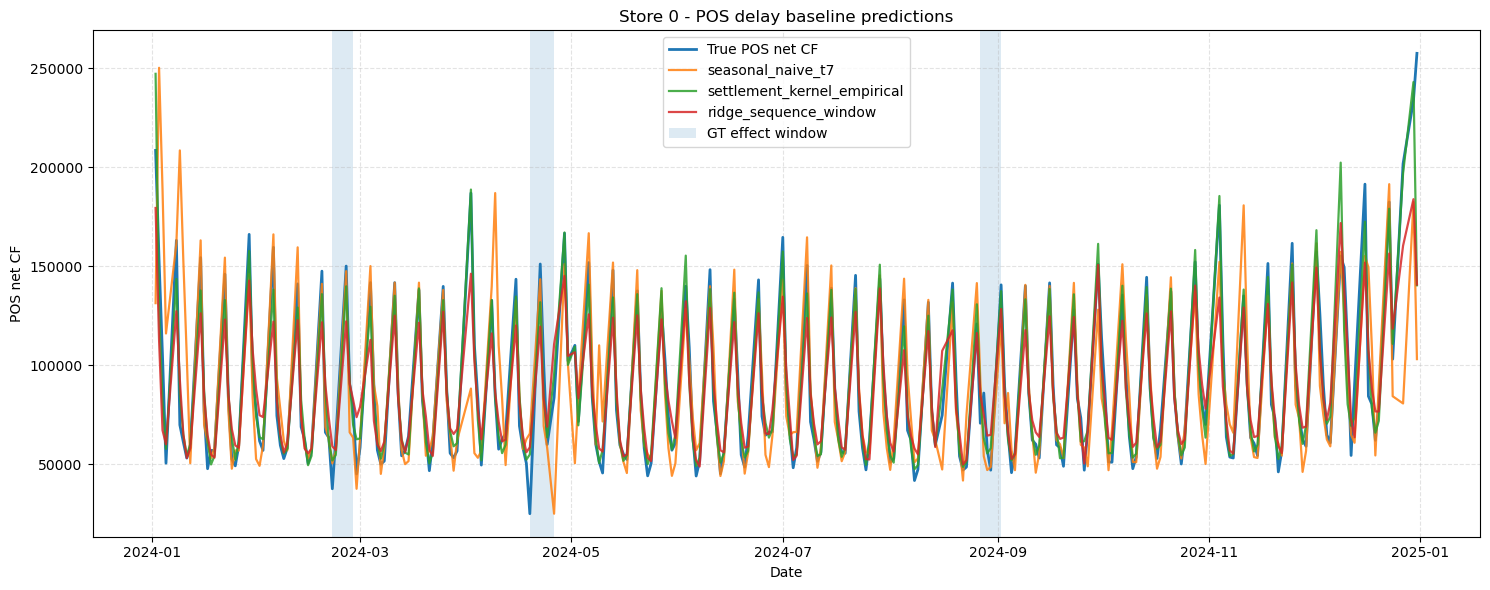

In [16]:
# =========================================================
# PLOT UTILITY
# =========================================================

def plot_baseline_predictions(
    outputs,
    store_id=None,
    start_date="2024-01-01",
    end_date="2024-12-31",
):
    daily_df = outputs["daily_df"].copy()
    daily_df["date"] = pd.to_datetime(daily_df["date"])

    plot_df = daily_df[
        (daily_df["date"] >= pd.to_datetime(start_date))
        & (daily_df["date"] <= pd.to_datetime(end_date))
    ].copy()

    if plot_df.empty:
        print("Nessun dato nell'intervallo selezionato.")
        return

    if store_id is None:
        store_id = plot_df["store_id"].iloc[0]

    plot_df = (
        plot_df[plot_df["store_id"] == store_id]
        .sort_values("date")
        .copy()
    )

    if plot_df.empty:
        print(f"Nessun dato per store_id={store_id}.")
        return

    lines_df = plot_df[plot_df["holiday"].astype(int) == 0].copy()

    fig, ax = plt.subplots(figsize=(15, 6))

    ax.plot(
        lines_df["date"],
        lines_df["pos_net_cf"],
        label="True POS net CF",
        linewidth=2,
    )

    pred_info = {
        "seasonal_naive_t7": "y_pred_seasonal_naive_t7",
        "settlement_kernel_empirical": "y_pred_settlement_kernel_empirical",
        "ridge_sequence_window": "y_pred_ridge_sequence_window",
    }

    for label, col in pred_info.items():
        if col in lines_df.columns:
            ax.plot(
                lines_df["date"],
                lines_df[col],
                label=label,
                linewidth=1.6,
                alpha=0.85,
            )

    gt = plot_df[
        (plot_df["is_pos_delay_effect_day"].astype(int) == 1)
        & (plot_df["pos_delay_event_id"] != -1)
    ]

    first_gt = True

    for _, g in gt.groupby("pos_delay_event_id"):
        ax.axvspan(
            g["date"].min(),
            g["date"].max(),
            alpha=0.15,
            label="GT effect window" if first_gt else None,
        )
        first_gt = False

    ax.set_title(f"Store {store_id} - POS delay baseline predictions")
    ax.set_xlabel("Date")
    ax.set_ylabel("POS net CF")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_baseline_predictions(
    main_outputs,
    store_id=None,
    start_date="2024-01-01",
    end_date="2024-12-31",
)

## Esecuzione sui dataset di sensitivity

Questa sezione valuta le baseline su tutti i dataset di sensitivity selezionati e le confronta con l'LSTM base.
Per impostazione predefinita viene usato `source_duration = 1`; le durate 2 e 3 possono essere incluse attivando `RUN_EXTENDED_SOURCE_DURATION_ANALYSIS`.

In [17]:
# =========================================================
# SENSITIVITY DATASETS
# =========================================================

MAIN_SOURCE_DURATION_FILTER = [1]
EXTENDED_SOURCE_DURATION_FILTER = [2, 3]

RUN_SENSITIVITY_BASELINES = True
RUN_EXTENDED_SOURCE_DURATION_ANALYSIS = False

# FORCE_RECOMPUTE è definito nella configurazione iniziale e vale anche qui.

SOURCE_DURATION_FILTER = MAIN_SOURCE_DURATION_FILTER.copy()
if RUN_EXTENDED_SOURCE_DURATION_ANALYSIS:
    SOURCE_DURATION_FILTER = MAIN_SOURCE_DURATION_FILTER + EXTENDED_SOURCE_DURATION_FILTER

DELAY_TYPES_FILTER = [
    "mild_delay",
    "moderate_delay",
    "strong_delay",
    "batch_backlog",
    "settlement_freeze",
]

RAW_BASELINE_RESULTS_PATH = OUTPUT_DIR / "sensitivity_baseline_results_raw.csv"
AGG_BASELINE_RESULTS_PATH = OUTPUT_DIR / "sensitivity_baseline_results_aggregated.csv"
MAIN_AGG_BASELINE_RESULTS_PATH = OUTPUT_DIR / "sensitivity_baseline_results_aggregated_source_duration_1.csv"
BY_TYPE_BASELINE_RESULTS_PATH = OUTPUT_DIR / "sensitivity_baseline_results_by_type.csv"
KERNEL_WEIGHTS_RESULTS_PATH = OUTPUT_DIR / "sensitivity_empirical_kernel_weights.csv"

if RUN_SENSITIVITY_BASELINES:
    datasets_df = list_pos_delay_sensitivity_datasets(
        BASE_SENSITIVITY_PATH,
        source_duration_filter=SOURCE_DURATION_FILTER,
        delay_types_filter=DELAY_TYPES_FILTER,
    )
else:
    datasets_df = pd.DataFrame()

datasets_df

,path,delay_type,source_duration,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,46
5,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,mild_delay,1,42
6,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,mild_delay,1,43
7,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,mild_delay,1,44
8,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,mild_delay,1,45
9,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,mild_delay,1,46


In [18]:
# =========================================================
# RUN OR LOAD SENSITIVITY BASELINES
# =========================================================

def _filter_cached_baseline_results(df):
    """
    Filtra i risultati salvati in base alle durate e ai delay type selezionati.
    """

    out = df.copy()

    if "source_duration" in out.columns:
        out = out[out["source_duration"].isin(SOURCE_DURATION_FILTER)].copy()

    if "delay_type" in out.columns:
        out = out[out["delay_type"].isin(DELAY_TYPES_FILTER)].copy()

    if "delay_type_dataset" in out.columns:
        out = out[out["delay_type_dataset"].isin(DELAY_TYPES_FILTER)].copy()

    return out.reset_index(drop=True)


def _baseline_cache_is_usable():
    """
    Verifica che i risultati salvati coprano le durate e le baseline richieste.
    """

    cache_paths = [
        RAW_BASELINE_RESULTS_PATH,
        BY_TYPE_BASELINE_RESULTS_PATH,
        KERNEL_WEIGHTS_RESULTS_PATH,
    ]

    if not all(path.exists() for path in cache_paths):
        return False

    raw_cache = pd.read_csv(RAW_BASELINE_RESULTS_PATH)

    if raw_cache.empty or "source_duration" not in raw_cache.columns:
        return False

    available_source_durations = set(
        raw_cache["source_duration"].dropna().astype(int).unique()
    )

    requested_source_durations = set(
        int(x) for x in SOURCE_DURATION_FILTER
    )

    expected_baselines = {
        "seasonal_naive_t7",
        "settlement_kernel_empirical",
        "ridge_sequence_window",
    }

    available_baselines = set(raw_cache.get("baseline", pd.Series(dtype=str)))

    return (
        requested_source_durations.issubset(available_source_durations)
        and expected_baselines.issubset(available_baselines)
    )


load_baseline_cache = (
    RUN_SENSITIVITY_BASELINES
    and not FORCE_RECOMPUTE
    and _baseline_cache_is_usable()
)

if load_baseline_cache:
    sensitivity_summary = _filter_cached_baseline_results(
        pd.read_csv(RAW_BASELINE_RESULTS_PATH)
    )

    sensitivity_by_type = _filter_cached_baseline_results(
        pd.read_csv(BY_TYPE_BASELINE_RESULTS_PATH)
    )

    sensitivity_kernel_weights = _filter_cached_baseline_results(
        pd.read_csv(KERNEL_WEIGHTS_RESULTS_PATH)
    )

    print("Risultati baseline caricati dai file salvati.")
    print(f"Raw: {RAW_BASELINE_RESULTS_PATH}")

else:
    all_summary_rows = []
    all_type_rows = []
    all_weight_rows = []

    if RUN_SENSITIVITY_BASELINES and not datasets_df.empty:

        start_time = time.time()

        for _, dataset_row in tqdm(
            datasets_df.iterrows(),
            total=len(datasets_df),
            desc="POS delay baseline datasets"
        ):
            csv_path = dataset_row["path"]

            df_dataset = pd.read_csv(csv_path)
            df_dataset["date"] = pd.to_datetime(df_dataset["date"])

            outputs = run_three_baselines_on_dataframe(
                df=df_dataset,
                detector_config=BASELINE_DETECTOR_CONFIG,
                ridge_alpha=1.0,
                train_size=TRAIN_SIZE,
                val_size=VAL_SIZE,
                max_delay=MAX_ORDINARY_SETTLEMENT_DELAY,
                ridge_window_size=RIDGE_SEQUENCE_WINDOW_SIZE,
                empirical_kernel_per_store=True,
            )

            weights = outputs["learned_kernel_weights"].copy()
            weights.insert(0, "delay_type_dataset", dataset_row["delay_type"])
            weights.insert(1, "source_duration", int(dataset_row["source_duration"]))
            weights.insert(2, "seed", int(dataset_row["seed"]))
            all_weight_rows.append(weights)

            for baseline_name, baseline_output in outputs["baselines"].items():
                detector_output = baseline_output["detector_output"]

                if detector_output is None:
                    continue

                summary = detector_output["summary"].copy()

                summary_row = {
                    "baseline": baseline_name,
                    "delay_type": dataset_row["delay_type"],
                    "source_duration": int(dataset_row["source_duration"]),
                    "seed": int(dataset_row["seed"]),
                    "path": str(csv_path),
                }
                summary_row.update(summary)
                summary_row.update({f"test_{k}": v for k, v in baseline_output["forecast_metrics_test"].items()})

                all_summary_rows.append(summary_row)

                gt_eval = detector_output["gt_eval"]

                if not gt_eval.empty:
                    by_type = summarize_gt_eval_by_type(gt_eval)
                    by_type.insert(0, "baseline", baseline_name)
                    by_type.insert(1, "delay_type_dataset", dataset_row["delay_type"])
                    by_type.insert(2, "source_duration", int(dataset_row["source_duration"]))
                    by_type.insert(3, "seed", int(dataset_row["seed"]))
                    all_type_rows.append(by_type)

        elapsed = time.time() - start_time
        print(f"Completato in {elapsed:.1f} secondi")

    sensitivity_summary = (
        pd.DataFrame(all_summary_rows)
        if all_summary_rows
        else pd.DataFrame()
    )

    sensitivity_by_type = (
        pd.concat(all_type_rows, ignore_index=True)
        if all_type_rows
        else pd.DataFrame()
    )

    sensitivity_kernel_weights = (
        pd.concat(all_weight_rows, ignore_index=True)
        if all_weight_rows
        else pd.DataFrame()
    )

sensitivity_summary.head()

Risultati baseline caricati dai file salvati.
Raw: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\baseline_comparison\sensitivity_baseline_results_raw.csv


,baseline,delay_type,source_duration,seed,path,n_gt_events,n_detected_events,tp,fp,fn,...,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,detected_window_mode,iou_threshold,test_mae,test_rmse,test_wape
0,seasonal_naive_t7,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,16,5,11,45,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,8096.608807,17512.569186,0.198020
1,settlement_kernel_empirical,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,56,42,14,8,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,3914.016218,8001.597544,0.095726
2,ridge_sequence_window,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,34,29,5,21,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,5422.250215,9876.747894,0.132788
3,seasonal_naive_t7,batch_backlog,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,16,5,11,45,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,8138.050393,17341.389220,0.199034
4,settlement_kernel_empirical,batch_backlog,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,52,38,14,12,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,3908.988914,8028.641379,0.095603


In [19]:
# =========================================================
# AGGREGAZIONE SENSITIVITY
# =========================================================


def _safe_div(num, den):
    return num / den if den > 0 else np.nan


def add_pooled_detection_metrics(df):
    """
    Aggiunge precision/recall/F1 pooled a partire da TP, FP e FN aggregati.
    Le metriche pooled sono preferibili per il confronto finale tra modelli.
    """

    out = df.copy()

    out["precision_pooled"] = [
        _safe_div(tp, tp + fp)
        for tp, fp in zip(out["tp_sum"], out["fp_sum"])
    ]

    out["recall_pooled"] = [
        _safe_div(tp, tp + fn)
        for tp, fn in zip(out["tp_sum"], out["fn_sum"])
    ]

    out["f1_pooled"] = [
        _safe_div(2 * p * r, p + r)
        if pd.notna(p) and pd.notna(r) else np.nan
        for p, r in zip(out["precision_pooled"], out["recall_pooled"])
    ]

    return out


if not sensitivity_summary.empty:
    sensitivity_agg = (
        sensitivity_summary
        .groupby(["baseline", "source_duration", "delay_type"], dropna=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events_sum=("n_gt_events", "sum"),
            n_detected_events_sum=("n_detected_events", "sum"),
            tp_sum=("tp", "sum"),
            fp_sum=("fp", "sum"),
            fn_sum=("fn", "sum"),
            precision_mean=("precision", "mean"),
            recall_mean=("recall", "mean"),
            f1_mean=("f1", "mean"),
            mean_iou=("mean_iou", "mean"),
            mean_detection_delay=("mean_detection_delay", "mean"),
            test_mae_mean=("test_mae", "mean"),
            test_rmse_mean=("test_rmse", "mean"),
            test_wape_mean=("test_wape", "mean"),
        )
        .reset_index()
    )

    sensitivity_agg = add_pooled_detection_metrics(sensitivity_agg)

    sensitivity_agg = sensitivity_agg.sort_values(
        ["source_duration", "delay_type", "baseline"]
    ).reset_index(drop=True)

    sensitivity_main_agg = sensitivity_agg[
        sensitivity_agg["source_duration"].isin(MAIN_SOURCE_DURATION_FILTER)
    ].copy()
else:
    sensitivity_agg = pd.DataFrame()
    sensitivity_main_agg = pd.DataFrame()

sensitivity_agg

,baseline,source_duration,delay_type,n_runs,n_gt_events_sum,n_detected_events_sum,tp_sum,fp_sum,fn_sum,precision_mean,recall_mean,f1_mean,mean_iou,mean_detection_delay,test_mae_mean,test_rmse_mean,test_wape_mean,precision_pooled,recall_pooled,f1_pooled
0,ridge_sequence_window,1,batch_backlog,5,250,173,142,31,108,0.821152,0.568,0.670992,0.546771,-3.835573,5405.975064,9832.178817,0.132389,0.820809,0.568,0.671395
1,seasonal_naive_t7,1,batch_backlog,5,250,88,23,65,227,0.265402,0.092,0.136420,0.541488,-1.840000,8097.474555,17373.618695,0.198041,0.261364,0.092,0.136095
2,settlement_kernel_empirical,1,batch_backlog,5,250,282,207,75,43,0.734232,0.828,0.777942,0.498504,-5.241890,3910.531891,8033.762324,0.095640,0.734043,0.828,0.778195
3,ridge_sequence_window,1,mild_delay,5,250,42,13,29,237,0.289719,0.052,0.087851,0.599681,-2.640000,5180.920956,9425.256125,0.126878,0.309524,0.052,0.089041
4,seasonal_naive_t7,1,mild_delay,5,250,81,17,64,233,0.210588,0.068,0.102767,0.505524,-4.600000,7611.700389,16779.295833,0.186161,0.209877,0.068,0.102719
5,settlement_kernel_empirical,1,mild_delay,5,250,122,39,83,211,0.319303,0.156,0.209390,0.596099,-3.226190,3628.009899,7393.011125,0.088731,0.319672,0.156,0.209677
6,ridge_sequence_window,1,moderate_delay,5,250,74,42,32,208,0.558571,0.168,0.256543,0.539808,-3.056566,5232.452270,9516.943045,0.128140,0.567568,0.168,0.259259
7,seasonal_naive_t7,1,moderate_delay,5,250,83,18,65,232,0.216912,0.072,0.108096,0.533478,-3.640000,7754.191134,16938.064141,0.189645,0.216867,0.072,0.108108
8,settlement_kernel_empirical,1,moderate_delay,5,250,176,96,80,154,0.545565,0.384,0.450694,0.518941,-4.188995,3698.442901,7554.246377,0.090453,0.545455,0.384,0.450704
9,ridge_sequence_window,1,settlement_freeze,5,250,225,195,30,55,0.866561,0.780,0.820844,0.541981,-3.286244,5544.705612,10265.113539,0.135787,0.866667,0.780,0.821053


In [20]:
# =========================================================
# SAVE SENSITIVITY RESULTS
# =========================================================

if not sensitivity_summary.empty:
    sensitivity_summary.to_csv(
        RAW_BASELINE_RESULTS_PATH,
        index=False,
    )

    sensitivity_agg.to_csv(
        AGG_BASELINE_RESULTS_PATH,
        index=False,
    )

    sensitivity_main_agg.to_csv(
        MAIN_AGG_BASELINE_RESULTS_PATH,
        index=False,
    )

    sensitivity_by_type.to_csv(
        BY_TYPE_BASELINE_RESULTS_PATH,
        index=False,
    )

    sensitivity_kernel_weights.to_csv(
        KERNEL_WEIGHTS_RESULTS_PATH,
        index=False,
    )

OUTPUT_DIR

WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/baseline_comparison')

## Confronto con LSTM base

I risultati dell'LSTM base sono letti dal CSV prodotto da `02-delay_type_sensitivity.py`.

Le baseline e l'LSTM vengono riportati nello stesso schema; precision, recall e $F_1$ pooled sono calcolati a partire dai conteggi `tp`, `fp` e `fn`.

In [21]:
# =========================================================
# LOAD LSTM BASE RESULTS
# =========================================================

LSTM_BASE_RESULTS_PATH = (
    POS_DELAY_RESULTS_DIR
    / "lstm_sensitivity"
    / "pos_delay_sensitivity_best_detector_results.csv"
)

REQUIRE_LSTM_BASE_RESULTS = False


def load_lstm_base_results(
    path=LSTM_BASE_RESULTS_PATH,
    source_duration_filter=None,
    delay_types_filter=None,
):
    """
    Carica i risultati dell'LSTM base già prodotti dal notebook
    02-delay_type_sensitivity.py.

    Se il file non esiste e REQUIRE_LSTM_BASE_RESULTS=False, restituisce
    un dataframe vuoto e permette di eseguire comunque il notebook baseline.
    """

    path = Path(path)

    if not path.exists():
        msg = (
            "Risultati LSTM base non trovati:\n"
            f"{path}\n\n"
            "Esegui prima 02-delay_type_sensitivity.py per generare "
            "pos_delay_sensitivity_best_detector_results.csv."
        )

        if REQUIRE_LSTM_BASE_RESULTS:
            raise FileNotFoundError(msg)

        print(msg)
        return pd.DataFrame()

    lstm_df = pd.read_csv(path)

    if source_duration_filter is not None and "source_duration" in lstm_df.columns:
        lstm_df = lstm_df[
            lstm_df["source_duration"].isin(source_duration_filter)
        ].copy()

    if delay_types_filter is not None and "delay_type" in lstm_df.columns:
        lstm_df = lstm_df[
            lstm_df["delay_type"].isin(delay_types_filter)
        ].copy()

    lstm_df["baseline"] = "lstm_base"
    lstm_df["path"] = lstm_df.get("path", "")

    return lstm_df.reset_index(drop=True)


lstm_base_raw = load_lstm_base_results(
    path=LSTM_BASE_RESULTS_PATH,
    source_duration_filter=SOURCE_DURATION_FILTER,
    delay_types_filter=DELAY_TYPES_FILTER,
)

lstm_base_raw.head()

,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_delay,...,seed,path,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,detected_window_mode,iou_threshold,baseline
0,50,68,50,18,0,0.735294,1.00,0.847458,0.477820,-5.680000,...,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,lstm_base
1,50,68,47,21,3,0.691176,0.94,0.796610,0.450905,-6.021277,...,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,lstm_base
2,50,69,50,19,0,0.724638,1.00,0.840336,0.431884,-6.520000,...,44,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,lstm_base
3,50,70,50,20,0,0.714286,1.00,0.833333,0.450422,-6.180000,...,45,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,lstm_base
4,50,66,48,18,2,0.727273,0.96,0.827586,0.437561,-6.437500,...,46,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,lstm_base


In [22]:
# =========================================================
# STANDARDIZZAZIONE SCHEMA RISULTATI
# =========================================================

RAW_COMPARISON_COLS = [
    "baseline",
    "delay_type",
    "source_duration",
    "seed",
    "path",
    "n_gt_events",
    "n_detected_events",
    "tp",
    "fp",
    "fn",
    "precision",
    "recall",
    "f1",
    "mean_iou",
    "mean_detection_delay",
    "score_col",
    "profile_window_size",
    "z_threshold",
    "min_consecutive",
    "gap_tolerance",
    "detected_window_mode",
    "iou_threshold",
    "test_mae",
    "test_rmse",
    "test_wape",
]


def standardize_raw_comparison_df(df, model_name=None):
    """
    Porta baseline e LSTM nello stesso schema tabellare.
    Le colonne non disponibili vengono aggiunte come NaN.
    """

    if df is None or df.empty:
        return pd.DataFrame(columns=RAW_COMPARISON_COLS)

    out = df.copy()

    if model_name is not None:
        out["baseline"] = model_name

    # Usa il nome della colonna prodotto dalle tabelle per tipo, quando presente.
    if "delay_type" not in out.columns and "delay_type_dataset" in out.columns:
        out["delay_type"] = out["delay_type_dataset"]

    for col in RAW_COMPARISON_COLS:
        if col not in out.columns:
            out[col] = np.nan

    return out[RAW_COMPARISON_COLS].copy()


baseline_raw_for_comparison = standardize_raw_comparison_df(
    sensitivity_summary,
)

lstm_base_for_comparison = standardize_raw_comparison_df(
    lstm_base_raw,
    model_name="lstm_base",
)

full_comparison_raw = pd.concat(
    [
        baseline_raw_for_comparison,
        lstm_base_for_comparison,
    ],
    ignore_index=True,
)

full_comparison_raw = full_comparison_raw.dropna(
    subset=["baseline", "delay_type", "source_duration"],
    how="any",
)

full_comparison_raw["source_duration"] = full_comparison_raw["source_duration"].astype(int)
full_comparison_raw["seed"] = full_comparison_raw["seed"].astype(int)

full_comparison_raw.head()

,baseline,delay_type,source_duration,seed,path,n_gt_events,n_detected_events,tp,fp,fn,...,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,detected_window_mode,iou_threshold,test_mae,test_rmse,test_wape
0,seasonal_naive_t7,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,16,5,11,45,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,8096.608807,17512.569186,0.198020
1,settlement_kernel_empirical,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,56,42,14,8,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,3914.016218,8001.597544,0.095726
2,ridge_sequence_window,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,34,29,5,21,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,5422.250215,9876.747894,0.132788
3,seasonal_naive_t7,batch_backlog,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,16,5,11,45,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,8138.050393,17341.389220,0.199034
4,settlement_kernel_empirical,batch_backlog,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,50,52,38,14,12,...,pos_cos,7,3.5,2,1,profile_windows_union,0.2,3908.988914,8028.641379,0.095603


In [23]:
# =========================================================
# AGGREGAZIONE FULL COMPARISON
# =========================================================

MODEL_ORDER = [
    "seasonal_naive_t7",
    "settlement_kernel_empirical",
    "ridge_sequence_window",
    "lstm_base",
]


def aggregate_full_comparison(df, group_cols):
    """
    Aggrega risultati event-level con metriche medie e metriche pooled.
    """

    if df is None or df.empty:
        return pd.DataFrame()

    agg = (
        df
        .groupby(group_cols, dropna=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events_sum=("n_gt_events", "sum"),
            n_detected_events_sum=("n_detected_events", "sum"),
            tp_sum=("tp", "sum"),
            fp_sum=("fp", "sum"),
            fn_sum=("fn", "sum"),
            precision_mean=("precision", "mean"),
            recall_mean=("recall", "mean"),
            f1_mean=("f1", "mean"),
            mean_iou=("mean_iou", "mean"),
            mean_detection_delay=("mean_detection_delay", "mean"),
            test_mae_mean=("test_mae", "mean"),
            test_rmse_mean=("test_rmse", "mean"),
            test_wape_mean=("test_wape", "mean"),
        )
        .reset_index()
    )

    agg = add_pooled_detection_metrics(agg)

    if "baseline" in agg.columns:
        agg["baseline_order"] = agg["baseline"].map(
            {name: i for i, name in enumerate(MODEL_ORDER)}
        ).fillna(len(MODEL_ORDER)).astype(int)

    return agg


full_comparison_by_type = aggregate_full_comparison(
    full_comparison_raw,
    ["baseline", "source_duration", "delay_type"],
)

if not full_comparison_by_type.empty:
    full_comparison_by_type = full_comparison_by_type.sort_values(
        ["source_duration", "delay_type", "baseline_order"]
    ).reset_index(drop=True)

model_comparison_pooled = aggregate_full_comparison(
    full_comparison_raw,
    ["baseline", "source_duration"],
)

if not model_comparison_pooled.empty:
    model_comparison_pooled = model_comparison_pooled.sort_values(
        ["source_duration", "baseline_order"]
    ).reset_index(drop=True)

model_comparison_pooled

,baseline,source_duration,n_runs,n_gt_events_sum,n_detected_events_sum,tp_sum,fp_sum,fn_sum,precision_mean,recall_mean,f1_mean,mean_iou,mean_detection_delay,test_mae_mean,test_rmse_mean,test_wape_mean,precision_pooled,recall_pooled,f1_pooled,baseline_order
0,seasonal_naive_t7,1,25,1250,426,104,322,1146,0.245344,0.0832,0.124135,0.518064,-3.018000,7944.952203,17248.731712,0.194311,0.244131,0.0832,0.124105,0
1,settlement_kernel_empirical,1,25,1250,1142,750,392,500,0.608936,0.6000,0.593420,0.524250,-4.366928,3816.812956,7855.084410,0.093348,0.656743,0.6000,0.627090,1
2,ridge_sequence_window,1,25,1250,655,497,158,753,0.655579,0.3976,0.474230,0.558643,-3.250307,5338.925926,9752.189709,0.130747,0.758779,0.3976,0.521785,2
3,lstm_base,1,25,1250,1527,1022,505,228,0.654482,0.8176,0.722805,0.474865,-5.421983,NaN,NaN,NaN,0.669286,0.8176,0.736046,3


In [24]:
# =========================================================
# TABELLA TESI - MODEL COMPARISON POOLED
# =========================================================

model_comparison_table = model_comparison_pooled.copy()

# Analisi principale: source_duration = 1
model_comparison_table = model_comparison_table[
    model_comparison_table["source_duration"] == 1
].copy()

model_comparison_table = model_comparison_table[
    [
        "baseline",
        "n_gt_events_sum",
        "n_detected_events_sum",
        "tp_sum",
        "fp_sum",
        "fn_sum",
        "precision_pooled",
        "recall_pooled",
        "f1_pooled",
        "mean_iou",
    ]
].copy()

model_comparison_table

,baseline,n_gt_events_sum,n_detected_events_sum,tp_sum,fp_sum,fn_sum,precision_pooled,recall_pooled,f1_pooled,mean_iou
0,seasonal_naive_t7,1250,426,104,322,1146,0.244131,0.0832,0.124105,0.518064
1,settlement_kernel_empirical,1250,1142,750,392,500,0.656743,0.6000,0.627090,0.524250
2,ridge_sequence_window,1250,655,497,158,753,0.758779,0.3976,0.521785,0.558643
3,lstm_base,1250,1527,1022,505,228,0.669286,0.8176,0.736046,0.474865


In [25]:
# =========================================================
# SAVE FULL COMPARISON
# =========================================================

if not full_comparison_raw.empty:
    full_comparison_raw.to_csv(
        OUTPUT_DIR / "sensitivity_full_comparison_raw.csv",
        index=False,
    )

    full_comparison_by_type.to_csv(
        OUTPUT_DIR / "sensitivity_full_comparison_by_type.csv",
        index=False,
    )

    model_comparison_pooled.to_csv(
        OUTPUT_DIR / "sensitivity_model_comparison_pooled.csv",
        index=False,
    )

    model_comparison_table.to_csv(
        OUTPUT_DIR / "sensitivity_model_comparison_table.csv",
        index=False,
    )

OUTPUT_DIR

WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/baseline_comparison')

## Grafici di confronto

I grafici usano le metriche pooled, perché sono più stabili per il confronto finale tra famiglie di modelli.

C:\Users\ciok4\AppData\Local\Temp\ipykernel_98584\863471497.py:262: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])


Figura salvata: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\baseline_comparison\figures\dashboard_model_comparison_precision_recall_f1_by_delay_type.png


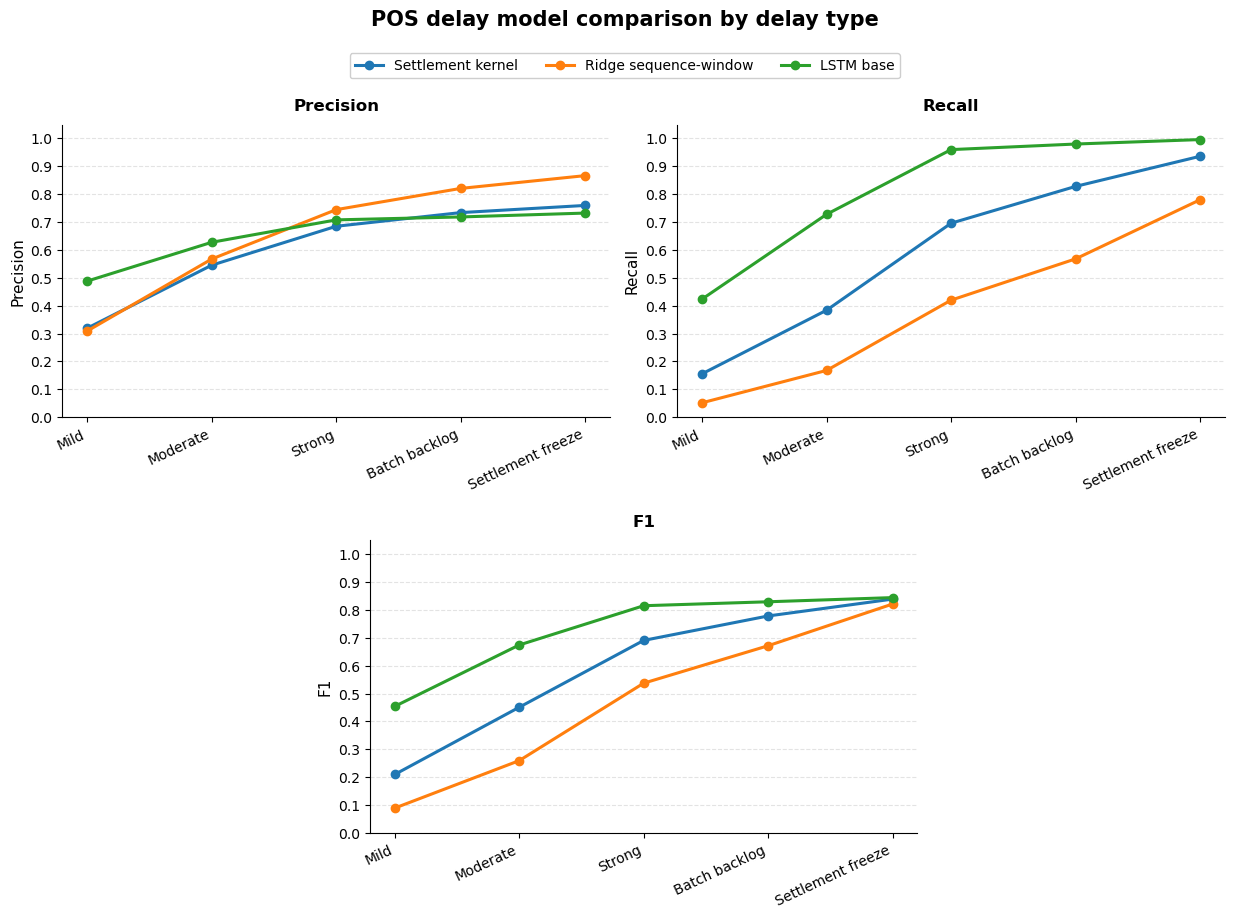

,baseline,model_label,delay_type,delay_label,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled,mean_iou
0,settlement_kernel_empirical,Settlement kernel,mild_delay,Mild,5,250,122,39,83,211,0.320,0.156,0.210,0.596
1,settlement_kernel_empirical,Settlement kernel,moderate_delay,Moderate,5,250,176,96,80,154,0.545,0.384,0.451,0.519
2,settlement_kernel_empirical,Settlement kernel,strong_delay,Strong,5,250,254,174,80,76,0.685,0.696,0.690,0.522
3,settlement_kernel_empirical,Settlement kernel,batch_backlog,Batch backlog,5,250,282,207,75,43,0.734,0.828,0.778,0.499
4,settlement_kernel_empirical,Settlement kernel,settlement_freeze,Settlement freeze,5,250,308,234,74,16,0.760,0.936,0.839,0.486
5,ridge_sequence_window,Ridge sequence-window,mild_delay,Mild,5,250,42,13,29,237,0.310,0.052,0.089,0.600
6,ridge_sequence_window,Ridge sequence-window,moderate_delay,Moderate,5,250,74,42,32,208,0.568,0.168,0.259,0.540
7,ridge_sequence_window,Ridge sequence-window,strong_delay,Strong,5,250,141,105,36,145,0.745,0.420,0.537,0.565
8,ridge_sequence_window,Ridge sequence-window,batch_backlog,Batch backlog,5,250,173,142,31,108,0.821,0.568,0.671,0.547
9,ridge_sequence_window,Ridge sequence-window,settlement_freeze,Settlement freeze,5,250,225,195,30,55,0.867,0.780,0.821,0.542


Punti del grafico salvati in: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\baseline_comparison\model_comparison_precision_recall_f1_by_delay_type_points.csv


In [26]:
def build_model_comparison_by_delay_type_points(
    full_comparison_raw,
    source_duration=1,
    models=None,
):
    """
    Costruisce la tabella dei punti rappresentati nel dashboard.

    Le metriche sono pooled:
    somma TP, FP, FN per modello e delay_type, poi calcolo di
    precision, recall e F1.
    """

    if models is None:
        models = [
            "settlement_kernel_empirical",
            "ridge_sequence_window",
            "lstm_base",
        ]

    df = full_comparison_raw.copy()

    df = df[
        (df["source_duration"].astype(int) == source_duration)
        & (df["baseline"].isin(models))
    ].copy()

    agg = (
        df
        .groupby(
            ["baseline", "delay_type"],
            as_index=False,
            dropna=False,
        )
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            mean_iou=("mean_iou", "mean"),
        )
    )

    agg["precision_pooled"] = [
        pooled_precision(tp, fp)
        for tp, fp in zip(agg["tp"], agg["fp"])
    ]

    agg["recall_pooled"] = [
        pooled_recall(tp, fn)
        for tp, fn in zip(agg["tp"], agg["fn"])
    ]

    agg["f1_pooled"] = [
        pooled_f1(p, r)
        for p, r in zip(
            agg["precision_pooled"],
            agg["recall_pooled"],
        )
    ]

    model_order = {
        "settlement_kernel_empirical": 0,
        "ridge_sequence_window": 1,
        "lstm_base": 2,
    }

    delay_order = {
        "mild_delay": 0,
        "moderate_delay": 1,
        "strong_delay": 2,
        "batch_backlog": 3,
        "settlement_freeze": 4,
    }

    model_labels = {
        "settlement_kernel_empirical": "Settlement kernel",
        "ridge_sequence_window": "Ridge sequence-window",
        "lstm_base": "LSTM base",
    }

    delay_labels = {
        "mild_delay": "Mild",
        "moderate_delay": "Moderate",
        "strong_delay": "Strong",
        "batch_backlog": "Batch backlog",
        "settlement_freeze": "Settlement freeze",
    }

    agg["model_order"] = agg["baseline"].map(model_order)
    agg["delay_order"] = agg["delay_type"].map(delay_order)
    agg["model_label"] = agg["baseline"].map(model_labels)
    agg["delay_label"] = agg["delay_type"].map(delay_labels)

    agg = (
        agg
        .sort_values(["model_order", "delay_order"])
        .reset_index(drop=True)
    )

    return agg


def plot_pos_delay_model_dashboard(
    full_comparison_raw,
    source_duration=1,
    save=True,
):
    """
    Disegna precision, recall e F1 pooled per tipologia di delay.
    """

    delay_order = [
        "mild_delay",
        "moderate_delay",
        "strong_delay",
        "batch_backlog",
        "settlement_freeze",
    ]

    delay_labels = [
        "Mild",
        "Moderate",
        "Strong",
        "Batch backlog",
        "Settlement freeze",
    ]

    model_order = [
        "settlement_kernel_empirical",
        "ridge_sequence_window",
        "lstm_base",
    ]

    model_labels = {
        "settlement_kernel_empirical": "Settlement kernel",
        "ridge_sequence_window": "Ridge sequence-window",
        "lstm_base": "LSTM base",
    }

    metric_info = {
        "precision_pooled": {
            "title": "Precision",
            "ylabel": "Precision",
        },
        "recall_pooled": {
            "title": "Recall",
            "ylabel": "Recall",
        },
        "f1_pooled": {
            "title": "F1",
            "ylabel": "F1",
        },
    }

    points_df = build_model_comparison_by_delay_type_points(
        full_comparison_raw=full_comparison_raw,
        source_duration=source_duration,
        models=model_order,
    )

    x = np.arange(len(delay_order))

    with plt.rc_context({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
    }):

        fig = plt.figure(figsize=(15.0, 9.2))

        gs = fig.add_gridspec(
            2,
            4,
            height_ratios=[1.0, 1.0],
            hspace=0.42,
            wspace=0.28,
        )

        ax_precision = fig.add_subplot(gs[0, 0:2])
        ax_recall = fig.add_subplot(gs[0, 2:4])
        ax_f1 = fig.add_subplot(gs[1, 1:3])

        axes = [
            (ax_precision, "precision_pooled"),
            (ax_recall, "recall_pooled"),
            (ax_f1, "f1_pooled"),
        ]

        handles = []
        labels = []

        for ax, metric in axes:

            for model_name in model_order:
                model_df = (
                    points_df[points_df["baseline"] == model_name]
                    .set_index("delay_type")
                    .reindex(delay_order)
                    .reset_index()
                )

                line, = ax.plot(
                    x,
                    model_df[metric],
                    marker="o",
                    markersize=6,
                    linewidth=2.2,
                    linestyle="-",
                    label=model_labels.get(model_name, model_name),
                )

                if metric == "precision_pooled":
                    handles.append(line)
                    labels.append(model_labels.get(model_name, model_name))

            ax.set_title(metric_info[metric]["title"], pad=10)
            ax.set_ylabel(metric_info[metric]["ylabel"])

            ax.set_xticks(x)
            ax.set_xticklabels(
                delay_labels,
                rotation=25,
                ha="right",
            )

            ax.set_ylim(0.0, 1.05)
            ax.set_yticks(np.arange(0.0, 1.01, 0.1))

            ax.grid(
                True,
                axis="y",
                linestyle="--",
                alpha=0.35,
            )
            ax.grid(False, axis="x")

        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.965),
            ncol=3,
            fontsize=10,
        )

        fig.suptitle(
            "POS delay model comparison by delay type",
            fontsize=15,
            fontweight="bold",
            y=1.005,
        )

        fig.tight_layout(rect=[0, 0, 1, 0.94])

        if save:
            fig_path = (
                FIGURES_DIR
                / "dashboard_model_comparison_precision_recall_f1_by_delay_type.png"
            )

            fig.savefig(
                fig_path,
                dpi=300,
                bbox_inches="tight",
            )

            print("Figura salvata:", fig_path)

        plt.show()
        plt.close(fig)

    return points_df


model_delay_type_dashboard_points = plot_pos_delay_model_dashboard(
    full_comparison_raw=full_comparison_raw,
    source_duration=1,
    save=True,
)

# =========================================================
# OUTPUT TABELLA DEI PUNTI RAPPRESENTATI
# =========================================================

model_delay_type_dashboard_points_display = model_delay_type_dashboard_points[
    [
        "baseline",
        "model_label",
        "delay_type",
        "delay_label",
        "n_runs",
        "n_gt_events",
        "n_detected_events",
        "tp",
        "fp",
        "fn",
        "precision_pooled",
        "recall_pooled",
        "f1_pooled",
        "mean_iou",
    ]
].copy()

for col in [
    "precision_pooled",
    "recall_pooled",
    "f1_pooled",
    "mean_iou",
]:
    model_delay_type_dashboard_points_display[col] = (
        model_delay_type_dashboard_points_display[col].round(3)
    )

display(model_delay_type_dashboard_points_display)

# =========================================================
# SAVE PLOTTED POINTS
# =========================================================

plot_points_path = (
    OUTPUT_DIR
    / "model_comparison_precision_recall_f1_by_delay_type_points.csv"
)

model_delay_type_dashboard_points.to_csv(
    plot_points_path,
    index=False,
)

print("Punti del grafico salvati in:", plot_points_path)